# Analisis Proporsi Data per Tahapan Pipeline
**Skripsi: Perbandingan Algoritma XGBoost dan Model IndoBERT dalam Klasifikasi Komentar Publik**

Notebook ini membandingkan proporsi data di **4 tahapan** pipeline Anda:

1. **Setelah Scraping** — data mentah hasil pengambilan komentar
2. **Setelah Cleaning** — data setelah dibersihkan (duplikat, spam, dsb dibuang)
3. **Setelah Labelling** — data setelah diberi label (manual + pseudo-label)
4. **Setelah Preprocessing** — data final yang siap masuk TF-IDF / tokenizer

Untuk tiap tahapan, notebook ini menampilkan:
- Proporsi jumlah komentar **per layanan** (BPJS Kesehatan / Coretax DJP / MBG)
- Proporsi **3 kelas** (Keluhan / Saran / Pujian) per layanan — *hanya untuk tahapan yang sudah punya label* (Labelling & Preprocessing)
- Perbandingan jumlah data **antar tahapan** (untuk melihat berapa banyak data "hilang" di tiap tahap, mis. akibat cleaning)

> ⚠️ **Yang perlu Anda sesuaikan**: bagian **KONFIGURASI** di bawah — isi path file CSV tiap tahapan
> dan nama kolom label (jika tahapan itu sudah punya label).

## 1. Import Library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

os.makedirs('outputs/figures', exist_ok=True)

print('✅ Library berhasil diimport')


✅ Library berhasil diimport


## 2. Mapping URL → Layanan

Mapping yang sama persis dengan notebook proporsi sebelumnya (`Analisis_Proporsi_Data_Per_Layanan.ipynb`),
supaya konsisten di semua tahapan.

In [2]:
# ============================================================
# MAPPING URL → LAYANAN
# ============================================================

CORETAX_URLS = [
    # Instagram — postingan umum (tidak ada akun spesifik)
    'https://www.instagram.com/reel/DXd-RSckWCU/',
    'https://www.instagram.com/p/DWYrb4PEwZ-/',
    'https://www.instagram.com/reel/DV2kPF7kg__/',
    'https://www.instagram.com/reel/DVScFc0k7sm/',
    'https://www.instagram.com/p/DM7H6ToJOLM/',
    'https://www.instagram.com/p/DX6bTT-kT18',
    'https://www.instagram.com/reel/DVvT5gZgTby/',
    'https://www.instagram.com/reel/DSbVBsoEq8B/',
    'https://www.instagram.com/p/DX2zbU9AS4x/',
    'https://www.instagram.com/p/DXwKIHGkUCt/',
    'https://www.instagram.com/p/DUFPyntkuvi/',
    'https://www.instagram.com/p/DNCnMRdTWgC/',
    # Instagram — akun ditjenpajakri & terkait
    'https://www.instagram.com/ditjenpajakri/p/DPQjaH5ktZj/',
    'https://www.instagram.com/pajakkupang/reel/DP2dxluAY10/',
    'https://www.instagram.com/pusdiklat.pajak/p/DPyK0N9j0Ge/',
    'https://www.instagram.com/ditjenpajakri/reel/DPoCl_4kqSY/',
    'https://www.instagram.com/ditjenpajakri/p/DPNnWgOEoJN/',
    'https://www.instagram.com/ditjenpajakri/reel/DPLFt1NkhQK/',
    'https://www.instagram.com/pajakbadsel/reel/DO7ThB5Ewhw/',
    'https://www.instagram.com/ditjenpajakri/p/DO5j92ekroJ/',
    'https://www.instagram.com/pajakbadsel/reel/DOxJksiE3nW/',
    'https://www.instagram.com/ditjenpajakri/p/DL9aUC3zWV8/',
    'https://www.instagram.com/ditjenpajakri/p/DL1Efc8zC3I/',
    'https://www.instagram.com/ditjenpajakri/p/DLg43FBxNij/',
    'https://www.instagram.com/ditjenpajakri/reel/DJ5iAMIy5rJ/',
    'https://www.instagram.com/ditjenpajakri/reel/DIu-HTmSi9J/',
    'https://www.instagram.com/ditjenpajakri/p/DIiGWj2PAk6/',
    'https://www.instagram.com/ditjenpajakri/p/DHupduuSR2K/',
    'https://www.instagram.com/ditjenpajakri/p/DHANVDCzzQb/',
    'https://www.instagram.com/ditjenpajakri/p/DGSfW2xRWAH/',
    'https://www.instagram.com/ditjenpajakri/p/DGPVXd_TfYv/',
    'https://www.instagram.com/ditjenpajakri/p/DGw2mA3vRuY/',
    'https://www.instagram.com/ditjenpajakri/p/DF47sKaz8qv/',
    'https://www.instagram.com/ditjenpajakri/p/DFwUbNzTqRU/',
    'https://www.instagram.com/ditjenpajakri/p/DFJsv5pzk6F/',
    # TikTok — akun ditjenpajakri
    'https://www.tiktok.com/@ditjenpajakri/video/7610336479398628615',
    'https://www.tiktok.com/@ditjenpajakri/video/7611003440457682196',
    'https://www.tiktok.com/@ditjenpajakri/video/7639553511885409556',
    'https://www.tiktok.com/@ditjenpajakri/video/7610277162599320850',
    'https://www.tiktok.com/@ditjenpajakri/video/7642568955202211093',
    'https://www.tiktok.com/@ditjenpajakri/video/7612935224527162644',
    'https://www.tiktok.com/@ditjenpajakri/video/7612933341184019732',
    'https://www.tiktok.com/@ditjenpajakri/video/7638817565682175252',
    'https://www.tiktok.com/@ditjenpajakri/video/7634364724825705748',
    'https://www.tiktok.com/@ditjenpajakri/video/7633631328118082836',
    'https://www.tiktok.com/@ditjenpajakri/video/7633400450959838485',
    'https://www.tiktok.com/@ditjenpajakri/video/7632135203305147668',
    'https://www.tiktok.com/@ditjenpajakri/video/7632208694012284180',
    'https://www.tiktok.com/@ditjenpajakri/video/7633273569090227476',
    'https://www.tiktok.com/@ditjenpajakri/video/7631375965263858965',
    'https://www.tiktok.com/@ditjenpajakri/video/7629563244511857941',
    'https://www.tiktok.com/@ditjenpajakri/video/7628449138367073557',
    'https://www.tiktok.com/@ditjenpajakri/video/7626951733964475668',
    'https://www.tiktok.com/@ditjenpajakri/video/7623968111607254292',
    'https://www.tiktok.com/@ditjenpajakri/video/7625439171577957652',
    'https://www.tiktok.com/@ditjenpajakri/video/7622887300917202196',
    'https://www.tiktok.com/@ditjenpajakri/video/7621153274967641365',
    'https://www.tiktok.com/@ditjenpajakri/video/7623771549253766420',
    'https://www.tiktok.com/@ditjenpajakri/video/7616590003392597268',
    'https://www.tiktok.com/@ditjenpajakri/video/7617717431275932949',
    'https://www.tiktok.com/@ditjenpajakri/video/7616289872101379348',
    'https://www.tiktok.com/@ditjenpajakri/video/7614075497210793236',
    'https://www.tiktok.com/@ditjenpajakri/video/7615905388944313607',
    'https://www.tiktok.com/@ditjenpajakri/video/7580205603176402183',
    'https://www.tiktok.com/@ditjenpajakri/video/7608418093806718224',
    'https://www.tiktok.com/@ditjenpajakri/video/7610265950746709255',
    'https://www.tiktok.com/@ditjenpajakri/video/7581298048752471304',
    'https://www.tiktok.com/@ditjenpajakri/video/7579820048710225159',
    'https://www.tiktok.com/@ditjenpajakri/video/7582110479372324104',
    'https://www.tiktok.com/@ditjenpajakri/video/7608772133015112967',
    'https://www.tiktok.com/@ditjenpajakri/video/7582485421897157908',
    'https://www.tiktok.com/@ditjenpajakri/video/7608416911319108881',
    'https://www.tiktok.com/@ditjenpajakri/video/7608032355621621013',
    'https://www.tiktok.com/@ditjenpajakri/video/7607670578572578069',
    'https://www.tiktok.com/@ditjenpajakri/video/7601175526811929877',
    'https://www.tiktok.com/@ditjenpajakri/video/7602858324622675220',
    'https://www.tiktok.com/@ditjenpajakri/video/7605431159438314772',
    'https://www.tiktok.com/@ditjenpajakri/video/7602444959555308820',
    'https://www.tiktok.com/@ditjenpajakri/video/7605907390227090695',
    'https://www.tiktok.com/@ditjenpajakri/video/7599584044728274196',
    'https://www.tiktok.com/@ditjenpajakri/video/7600287432180878613',
    'https://www.tiktok.com/@ditjenpajakri/video/7597250544717106440',
    'https://www.tiktok.com/@ditjenpajakri/video/7598531875577023751',
    'https://www.tiktok.com/@ditjenpajakri/video/7593252699798359314',
    'https://www.tiktok.com/@ditjenpajakri/video/7591697318173232404',
    'https://www.tiktok.com/@ditjenpajakri/video/7589488964541648148',
    'https://www.tiktok.com/@ditjenpajakri/video/7592253625523588370',
    'https://www.tiktok.com/@ditjenpajakri/video/7596906773584399623',
    'https://www.tiktok.com/@ditjenpajakri/video/7592535530936569106',
    'https://www.tiktok.com/@ditjenpajakri/video/7586937139745770773',
    'https://www.tiktok.com/@ditjenpajakri/video/7585472755408063765',
    'https://www.tiktok.com/@ditjenpajakri/video/7586510071551577365',
    'https://www.tiktok.com/@ditjenpajakri/video/7582883557480090900',
    'https://www.tiktok.com/@ditjenpajakri/video/7563580670468017428',
    'https://www.tiktok.com/@ditjenpajakri/video/7579166789955767570',
    'https://www.tiktok.com/@ditjenpajakri/video/7578727402524708104',
    'https://www.tiktok.com/@ditjenpajakri/video/7574633950237216018',
    'https://www.tiktok.com/@ditjenpajakri/video/7576909005411372306',
    'https://www.tiktok.com/@ditjenpajakri/video/7562173039345929493',
    'https://www.tiktok.com/@ditjenpajakri/video/7573507124303596818',
    'https://www.tiktok.com/@ditjenpajakri/video/7575063678135930119',
    'https://www.tiktok.com/@ditjenpajakri/video/7573944503346662674',
    'https://www.tiktok.com/@ditjenpajakri/video/7576930066320411911',
    'https://www.tiktok.com/@ditjenpajakri/video/7576470851323776274',
    'https://www.tiktok.com/@ditjenpajakri/video/7576126100942687506',
    'https://www.tiktok.com/@ditjenpajakri/video/7577678273212091666',
    'https://www.tiktok.com/@ditjenpajakri/video/7561711511815671058',
    'https://www.tiktok.com/@ditjenpajakri/video/7563205744783412500',
    'https://www.tiktok.com/@ditjenpajakri/video/7577272670329376007',
    'https://www.tiktok.com/@ditjenpajakri/video/7571655734899789063',
    'https://www.tiktok.com/@ditjenpajakri/video/7572416544806948104',
    'https://www.tiktok.com/@ditjenpajakri/video/7571310461757574420',
    'https://www.tiktok.com/@ditjenpajakri/video/7568692034895121682',
    'https://www.tiktok.com/@ditjenpajakri/video/7564356823722069256',
    'https://www.tiktok.com/@ditjenpajakri/video/7565810963434261781',
    'https://www.tiktok.com/@ditjenpajakri/video/7565030236643937556',
    'https://www.tiktok.com/@ditjenpajakri/video/7566542840612785415',
    'https://www.tiktok.com/@ditjenpajakri/video/7566905877278575892',
    'https://www.tiktok.com/@ditjenpajakri/video/7567180150207483156',
    'https://www.tiktok.com/@ditjenpajakri/video/7568418955673570580',
    'https://www.tiktok.com/@ditjenpajakri/video/7563866329980112136',
    'https://www.tiktok.com/@ditjenpajakri/video/7556953650313153799',
    'https://www.tiktok.com/@ditjenpajakri/video/7556183049059175698',
    'https://www.tiktok.com/@ditjenpajakri/video/7561341071838563592',
    'https://www.tiktok.com/@ditjenpajakri/video/7558061399767862546',
    'https://www.tiktok.com/@ditjenpajakri/video/7560583609413799224',
    'https://www.tiktok.com/@ditjenpajakri/video/7556533111987768583',
    'https://www.tiktok.com/@ditjenpajakri/video/7560989401342364946',
    'https://www.tiktok.com/@ditjenpajakri/video/7553452699715439873',
    'https://www.tiktok.com/@ditjenpajakri/video/7555467966142500114',
    'https://www.tiktok.com/@ditjenpajakri/video/7559549763142585618',
    'https://www.tiktok.com/@ditjenpajakri/video/7554200178459200769',
    # TikTok — akun lain terkait Coretax/pajak
    'https://www.tiktok.com/@ummasafina/video/7606324081310321927',
    'https://www.tiktok.com/@aadon94/video/7614406255871855892',
    'https://www.tiktok.com/@pajakjktsawahbesardua/video/7634369770053258504',
    'https://www.tiktok.com/@rillychannel/video/7605569988665019668',
    'https://www.tiktok.com/@coffeeplusss/video/7613693355385457941',
    'https://www.tiktok.com/@xbbpx/video/7616781656699014420',
    'https://www.tiktok.com/@liputan6.sctv/video/7621442575928528129',
    'https://www.tiktok.com/@inilahcom/video/7557958553273748743',
    'https://www.tiktok.com/@2ndaccount404/video/7590726295466593556',
    'https://www.tiktok.com/@ariazhar_/video/7467917427133746438',
    'https://www.tiktok.com/@lawakan.corporate/video/7475279661866437894',
    'https://www.tiktok.com/@rillychannel/video/7603019653971037461',
    'https://www.tiktok.com/@ditjenpajakri/video/7528274046279093512',
    'https://www.tiktok.com/@wiketrianaa/video/7468622994462477574',
    'https://www.tiktok.com/@fxchandra/video/7590978498584431892',
]

BPJS_URLS = [
    # Instagram — postingan umum
    'https://www.instagram.com/reel/DYfSoAMCLbk/',
    'https://www.instagram.com/reel/DXrT9W6oHrv/',
    'https://www.instagram.com/reel/DXecV8ticye/',
    'https://www.instagram.com/reel/DXea5HrD9Wq/',
    'https://www.instagram.com/reel/DXZJx57gM7s/',
    'https://www.instagram.com/p/DXVo_2hj4t8/',
    'https://www.instagram.com/p/DXOcqQxlKc0/',
    'https://www.instagram.com/reel/DVsm41_E0K2/',
    'https://www.instagram.com/reel/DVf7NZZkVyL/',
    'https://www.instagram.com/reel/DNSZNEwSo7E/',
    # Instagram — akun bpjskesehatan_ri & terkait
    'https://www.instagram.com/bpjskesehatan_ri/p/DO6EIPujOYw/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DOqGjSWkxvX/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DOai57FgLPt/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DP09dkjjZhj/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DPxoS2YDRK5/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DPoNY-Ckiyk/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DPix6eiDejg/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DPdwCGODwFz/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DPRA3Swjdth/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DPLlUs6jm4p/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DPF8NdIkrhF/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DO-y-bqiTyZ/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DO8OTtjCrA1/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOyZgkiifU1/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOk6O7WgUDD/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOhhnPuktYM/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOdR3HSkXVR/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DON4AFWE0X6/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DOLfw2uDYgD/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOFuU_ngZ13/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DN79G7eDc7I/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DOAX5hsEqy7/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNkQD1vPG58/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNiGSEQSyM-/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNbv8chpzrh/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DN5EmlFjq8F/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DN2ofl_6k8X/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DNR7LDCsr8g/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNIg2bgI-l5/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNGNegXNFOK/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DNDV5_gBBWO/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DM0ICKyynJE/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DMw1rKhuUZX/',
    'https://www.instagram.com/infojkntasikmalaya/reel/DMtonq6zS_F/',
    'https://www.instagram.com/bpjskesehatan_ri/reel/DMp5Ld9ItYd/',
    'https://www.instagram.com/bpjskesehatan_ri/p/DMhjpb6MNK0/',
    # TikTok — akun bpjskesehatan_ri
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7615529544535051531',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7618211945195375873',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7620754438478744833',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7617693988144811284',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7619489378515258642',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7616216247960603925',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7613946885404986625',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7611193345955728651',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7566857682439703820',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7553225651256429835',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7558782296875322635',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7642964280115088661',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7640050298530041109',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7640117379577498888',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7638816117141687559',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7638601580090117397',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7637365780878740757',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7636344539166330130',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7637071045169646868',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7635108214794734856',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7634482565944036629',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7634400244423298311',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7633800430807485713',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7631183346621566226',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7631948110708641042',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7629218860129946897',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7628096541500378388',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7626674148789554450',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7626343540599180551',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7623801426061380881',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7623789508764388609',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7623719150606634257',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7621938240953601297',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7611088368176352523',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7610701828895952184',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7581419432522550539',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7582536482653523218',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7583194266420268344',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7610335410023189816',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7579924003138145548',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7580373436057324812',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7605026014728703288',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7603732313712643384',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7610274398762700044',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7598166974539058443',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7595858490950716688',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7597671835764837644',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7603373431572204856',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7599214151210159372',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7601138047907859723',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7601036468588399883',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7603719076355116300',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7603268600610278668',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7594795560800947477',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7589633131410394380',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7586669969354640651',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7586973126135713080',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7584408405230701880',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7585477968533687563',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7585918768262516024',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7589500587817946380',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7592913655319170325',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7584377474612612408',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7543195813762059576',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7543548143430815032',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7576604738838334776',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7576227456479251723',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7569060917569441044',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7575182913273154872',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7575002074597870904',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7572814093376179512',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7571464668569554184',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7552917035404102920',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7560553682052402443',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7565846162402512184',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7561402368219172107',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7562840062333881612',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7555439291833404728',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7566955134232710411',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7564368126675111186',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7553964407621979403',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7555420575510891787',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7563603855188004108',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7563594811962330380',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7564735102408854796',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7550615624989379848',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7544602159438941458',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7549867185938681093',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7548766158762102021',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7543963604069010744',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7542828225437666566',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7540547429867719941',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7540239162390203656',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7533601411632844040',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7535804922726567174',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7536218294194490629',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7536550016505089285',
    'https://www.tiktok.com/@bpjskesehatan_ri/video/7534687503215758648',
    # TikTok — akun lain terkait BPJS
    'https://www.tiktok.com/@dokterasuransi_id/video/7591284580162882836',
    'https://www.tiktok.com/@ceelmuluu/video/7629484569808342290',
    'https://www.tiktok.com/@whithat90/video/7602802428559281426',
    'https://www.tiktok.com/@jeffersonchiaxxo/video/7604821753071750407',
    'https://www.tiktok.com/@memecatcorporate/video/7463024940799790341',
    'https://www.tiktok.com/@kara.asmaranala/video/7608028748603985170',
    'https://www.tiktok.com/@risyadandson/video/7625604545632161032',
    'https://www.tiktok.com/@aalisa.na/video/7598141299467783431',
]

MBG_URLS = [
    # Instagram — postingan umum
    'https://www.instagram.com/p/DWVXhkrk__j/',
    'https://www.instagram.com/p/DXgjNKaDO2r/',
    'https://www.instagram.com/p/DYuQExygdrV/',
    'https://www.instagram.com/p/DYrGNJOFIRc/',
    'https://www.instagram.com/p/DYomtlKARQQ/',
    'https://www.instagram.com/reel/DYWUUopJgXC/',
    'https://www.instagram.com/p/DYRquOxifSj/',
    'https://www.instagram.com/reel/DYKD0t3Jxtw/',
    'https://www.instagram.com/reel/DYE4JXvJGqS/',
    'https://www.instagram.com/reel/DYmu1e6PyWi/',
    'https://www.instagram.com/reel/DT-S7QPicLA/',
    'https://www.instagram.com/reel/DYWnJzzpojp/',
    # Instagram — akun badangizinasional.ri, kabarmbg, menumbg, sppg, bakom, dll.
    'https://www.instagram.com/badangizinasional.ri/reel/DHOMwBSp49K/',
    'https://www.instagram.com/badangizinasional.ri/p/DPD1MBfiboG/',
    'https://www.instagram.com/kabarmbg/p/DOfbBcvgZsH/',
    'https://www.instagram.com/badangizinasional.ri/p/DNW6qmJpVN1/',
    'https://www.instagram.com/menumbg/p/DO_CPNvkkOm/',
    'https://www.instagram.com/sppg.desa4sukumenanti/reel/DPAvRkhEp9E/',
    'https://www.instagram.com/sppgcimalaka/p/DOr3qMvkwR5/',
    'https://www.instagram.com/sppg_seyegan.01/reel/DKdxfWDywLR/',
    'https://www.instagram.com/sppg.pontianakselatan/p/DJI2gLNzPUS/',
    'https://www.instagram.com/kabarmbg/p/DIoMuyoBtF5/',
    'https://www.instagram.com/sppgcimalaka/p/DOcVfj9E77-/',
    'https://www.instagram.com/sppg.surade/p/DLQ6oDhyS9m/',
    'https://www.instagram.com/sppg_prabumulihtimur/p/DLQnmHZTYKk/',
    'https://www.instagram.com/sppg_prabumulihtimur/reel/DKK3gyaTxjP/',
    'https://www.instagram.com/kabarmbg/p/DO74Uc0AS6p/',
    'https://www.instagram.com/badangizinasional.ri/reel/DNW4DjIyMyY/',
    'https://www.instagram.com/badangizinasional.ri/reel/DKwWbx5p8Ib/',
    'https://www.instagram.com/badangizinasional.ri/reel/DKbfERlJHSh/',
    'https://www.instagram.com/badangizinasional.ri/reel/DP5jvMCCSPb/',
    'https://www.instagram.com/badangizinasional.ri/reel/DPoJSPICas5/',
    'https://www.instagram.com/badangizinasional.ri/p/DPnznd3iRqx/',
    'https://www.instagram.com/badangizinasional.ri/reel/DPlllCJCW3D/',
    'https://www.instagram.com/badangizinasional.ri/reel/DPi1IjgCbmx/',
    'https://www.instagram.com/badangizinasional.ri/reel/DPiJuYRCSbm/',
    'https://www.instagram.com/badangizinasional.ri/p/DPh4wuziRU0/',
    'https://www.instagram.com/badangizinasional.ri/p/DPfHAemAXCL/',
    'https://www.instagram.com/badangizinasional.ri/p/DPdQV0UifqC/',
    'https://www.instagram.com/badangizinasional.ri/p/DPU96qJgbmY/',
    'https://www.instagram.com/badangizinasional.ri/reel/DPSTDh7CeL7/',
    'https://www.instagram.com/badangizinasional.ri/p/DPNzqq6idw1/',
    'https://www.instagram.com/badangizinasional.ri/p/DPK-v8aCcCe/',
    'https://www.instagram.com/badangizinasional.ri/p/DPJClpnCa74/',
    'https://www.instagram.com/smpn1.panumbangan/reel/DK3w6JCTsEX/',
    'https://www.instagram.com/official_sdnegeri128sukarami/reel/DIveB_aBjc-/',
    'https://www.instagram.com/official_sdnegeri128sukarami/reel/DI00iM5hWZh/',
    'https://www.instagram.com/bail_30/reel/DOtEgTGkkN_/',
    'https://www.instagram.com/bakom.ri/p/DPgCdS9D69B/',
    'https://www.instagram.com/bakom.ri/reel/DPVGflWj-lE/',
    'https://www.instagram.com/bakom.ri/reel/DPTNq88j57l/',
    'https://www.instagram.com/bakom.ri/reel/DPSeiXSjxEh/',
    'https://www.instagram.com/bakom.ri/reel/DPQYfguj6bg/',
    'https://www.instagram.com/bakom.ri/reel/DPNtJfPj72h/',
    'https://www.instagram.com/cekfakta.ri/p/DPIu3fvCQ4_/',
    'https://www.instagram.com/bakom.ri/p/DPGTdmiEqIR/',
    'https://www.instagram.com/bakom.ri/reel/DPEjCRvj83S/',
    # TikTok — akun badangizinasional.ri
    'https://www.tiktok.com/@badangizinasional.ri/video/7635827943326895380',
    'https://www.tiktok.com/@badangizinasional.ri/video/7634381692983069972',
    'https://www.tiktok.com/@badangizinasional.ri/video/7635538851531967765',
    'https://www.tiktok.com/@badangizinasional.ri/video/7634863235061058836',
    'https://www.tiktok.com/@badangizinasional.ri/video/7643681282987281685',
    'https://www.tiktok.com/@badangizinasional.ri/video/7634796715974970644',
    'https://www.tiktok.com/@badangizinasional.ri/video/7643450674180574484',
    'https://www.tiktok.com/@badangizinasional.ri/video/7641824322327285013',
    'https://www.tiktok.com/@badangizinasional.ri/video/7641779519241604373',
    'https://www.tiktok.com/@badangizinasional.ri/video/7642581254906432789',
    'https://www.tiktok.com/@badangizinasional.ri/video/7641445706888219925',
    'https://www.tiktok.com/@badangizinasional.ri/video/7641207134759308564',
    'https://www.tiktok.com/@badangizinasional.ri/video/7641096739490893077',
    'https://www.tiktok.com/@badangizinasional.ri/video/7640822756023586068',
    'https://www.tiktok.com/@badangizinasional.ri/video/7640063063802023189',
    'https://www.tiktok.com/@badangizinasional.ri/video/7639578514798169365',
    'https://www.tiktok.com/@badangizinasional.ri/video/7639989713062939924',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638868681044282644',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638917606824758548',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638845808875539732',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638620256948325653',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638550472952990996',
    'https://www.tiktok.com/@badangizinasional.ri/video/7638523788497358101',
    'https://www.tiktok.com/@badangizinasional.ri/video/7637487335839452436',
    'https://www.tiktok.com/@badangizinasional.ri/video/7637149926643731732',
    'https://www.tiktok.com/@badangizinasional.ri/video/7637398715250101525',
    'https://www.tiktok.com/@badangizinasional.ri/video/7636752632299670804',
    'https://www.tiktok.com/@badangizinasional.ri/video/7636284981152615700',
    'https://www.tiktok.com/@badangizinasional.ri/video/7636233736564231444',
    'https://www.tiktok.com/@badangizinasional.ri/video/7635886146836352276',
    'https://www.tiktok.com/@badangizinasional.ri/video/7590172727617555720',
    'https://www.tiktok.com/@badangizinasional.ri/video/7590172131363720455',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633301786090016021',
    'https://www.tiktok.com/@badangizinasional.ri/video/7590171261456731410',
    'https://www.tiktok.com/@badangizinasional.ri/video/7590171816296008968',
    'https://www.tiktok.com/@badangizinasional.ri/video/7634014461233237269',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633301148358757652',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633638025506999572',
    'https://www.tiktok.com/@badangizinasional.ri/video/7634087044716694805',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633681099742301461',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633712262015962388',
    'https://www.tiktok.com/@badangizinasional.ri/video/7633047914297724181',
    'https://www.tiktok.com/@badangizinasional.ri/video/7631474481458154772',
    'https://www.tiktok.com/@badangizinasional.ri/video/7632294235995180308',
    'https://www.tiktok.com/@badangizinasional.ri/video/7631427168702057748',
    'https://www.tiktok.com/@badangizinasional.ri/video/7631165905954753813',
    'https://www.tiktok.com/@badangizinasional.ri/video/7631121611420110101',
    'https://www.tiktok.com/@badangizinasional.ri/video/7631060283724746005',
    'https://www.tiktok.com/@badangizinasional.ri/video/7630728575397776660',
    'https://www.tiktok.com/@badangizinasional.ri/video/7619538555014024469',
    'https://www.tiktok.com/@badangizinasional.ri/video/7616296419267218709',
    'https://www.tiktok.com/@badangizinasional.ri/video/7615943385836195092',
    'https://www.tiktok.com/@badangizinasional.ri/video/7613246514743266581',
    'https://www.tiktok.com/@badangizinasional.ri/video/7608781644769660180',
    'https://www.tiktok.com/@badangizinasional.ri/video/7607772298698984724',
    'https://www.tiktok.com/@badangizinasional.ri/video/7615544551624756501',
    'https://www.tiktok.com/@badangizinasional.ri/video/7590174555042237703',
    'https://www.tiktok.com/@badangizinasional.ri/video/7596981442509409556',
    'https://www.tiktok.com/@badangizinasional.ri/video/7600295815806029077',
    'https://www.tiktok.com/@badangizinasional.ri/video/7582156433089629458',
    'https://www.tiktok.com/@badangizinasional.ri/video/7581865638503763218',
    'https://www.tiktok.com/@badangizinasional.ri/video/7588493858791558420',
    'https://www.tiktok.com/@badangizinasional.ri/video/7587546225080012050',
    'https://www.tiktok.com/@badangizinasional.ri/video/7587936089629887765',
    'https://www.tiktok.com/@badangizinasional.ri/video/7588493966119619860',
    'https://www.tiktok.com/@badangizinasional.ri/video/7588829759560387858',
    'https://www.tiktok.com/@badangizinasional.ri/video/7581708017100475666',
    'https://www.tiktok.com/@badangizinasional.ri/video/7581799017030470919',
    'https://www.tiktok.com/@badangizinasional.ri/video/7589422708023250194',
    'https://www.tiktok.com/@badangizinasional.ri/video/7586865724262567175',
    'https://www.tiktok.com/@badangizinasional.ri/video/7586556322359872789',
    'https://www.tiktok.com/@badangizinasional.ri/video/7586227636028951816',
    'https://www.tiktok.com/@badangizinasional.ri/video/7585901158301011208',
    'https://www.tiktok.com/@badangizinasional.ri/video/7585457109093993735',
    'https://www.tiktok.com/@badangizinasional.ri/video/7587201131055533333',
    'https://www.tiktok.com/@badangizinasional.ri/video/7585496742653693192',
    'https://www.tiktok.com/@badangizinasional.ri/video/7585163283112529170',
    'https://www.tiktok.com/@badangizinasional.ri/video/7585015527098158344',
    'https://www.tiktok.com/@badangizinasional.ri/video/7583983541000703239',
    'https://www.tiktok.com/@badangizinasional.ri/video/7584326578700684564',
    'https://www.tiktok.com/@badangizinasional.ri/video/7583870101280083218',
    'https://www.tiktok.com/@badangizinasional.ri/video/7584240338525539605',
    'https://www.tiktok.com/@badangizinasional.ri/video/7584654829381799175',
    'https://www.tiktok.com/@badangizinasional.ri/video/7584064910137609480',
    'https://www.tiktok.com/@badangizinasional.ri/video/7583310744184196360',
    'https://www.tiktok.com/@badangizinasional.ri/video/7582428161573391623',
    'https://www.tiktok.com/@badangizinasional.ri/video/7582770915839167751',
    'https://www.tiktok.com/@badangizinasional.ri/video/7582556456247987474',
    'https://www.tiktok.com/@badangizinasional.ri/video/7581299776738577682',
    'https://www.tiktok.com/@badangizinasional.ri/video/7580683987836865810',
    'https://www.tiktok.com/@badangizinasional.ri/video/7580390400679120146',
    'https://www.tiktok.com/@badangizinasional.ri/video/7580737964620172552',
    'https://www.tiktok.com/@badangizinasional.ri/video/7577417405731818770',
    'https://www.tiktok.com/@badangizinasional.ri/video/7579520143902936328',
    'https://www.tiktok.com/@badangizinasional.ri/video/7579164757874363656',
    'https://www.tiktok.com/@badangizinasional.ri/video/7578751422473260306',
    'https://www.tiktok.com/@badangizinasional.ri/video/7580001667588934919',
    'https://www.tiktok.com/@badangizinasional.ri/video/7579063014217813266',
    'https://www.tiktok.com/@badangizinasional.ri/video/7580159066123685138',
    'https://www.tiktok.com/@badangizinasional.ri/video/7579626865887890696',
    # TikTok — akun lain terkait MBG
    'https://www.tiktok.com/@sppgsrkkarimunting/video/7626943348158287125',
    'https://www.tiktok.com/@na_nasgor123/video/7628177588770458901',
    'https://www.tiktok.com/@nvn.idn/video/7639439324274085138',
    'https://www.tiktok.com/@growthmotion.id/video/7639228546753236231',
    'https://www.tiktok.com/@lini.publik/video/7620671249559211285',
    'https://www.tiktok.com/@liputan6.sctv/video/7638910407763168533',
    'https://www.tiktok.com/@naniksdeyang/video/7637868806878088456',
]

# Buat dictionary untuk lookup cepat
url_to_layanan = {}
for url in CORETAX_URLS:
    url_to_layanan[url.strip()] = 'Coretax DJP'
for url in BPJS_URLS:
    url_to_layanan[url.strip()] = 'BPJS Kesehatan'
for url in MBG_URLS:
    url_to_layanan[url.strip()] = 'MBG'

print(f'✅ Mapping URL selesai dibuat')
print(f'   Total URL Coretax : {len(CORETAX_URLS)}')
print(f'   Total URL BPJS    : {len(BPJS_URLS)}')
print(f'   Total URL MBG     : {len(MBG_URLS)}')
print(f'   Total URL mapping : {len(url_to_layanan)}')

✅ Mapping URL selesai dibuat
   Total URL Coretax : 147
   Total URL BPJS    : 152
   Total URL MBG     : 164
   Total URL mapping : 463


## 3. KONFIGURASI — Sesuaikan dengan File Anda

Isi path CSV untuk tiap tahapan. Kalau salah satu tahapan belum punya kolom label
(misal Scraping & Cleaning biasanya belum dilabel), biarkan `kolom_label: None` —
notebook akan otomatis melewati grafik proporsi kelas untuk tahapan itu.

`kolom_url` adalah nama kolom yang berisi link postingan (dipakai untuk mapping ke layanan).

In [6]:
# ============================================================
# ⚠️ GANTI path, kolom_url, dan kolom_label sesuai dataset Anda
# ============================================================
TAHAPAN = {
    'Setelah Scraping': {
        'path': '../data/raw/combined_all_data.csv',
        'kolom_url': 'postUrl',
        'kolom_label': None,          # scraping belum ada label
    },
    'Setelah Cleaning': {
        'path': '../data/interim/cleaned_data.csv',
        'kolom_url': 'postUrl',
        'kolom_label': None,          # cleaning belum ada label
    },
    'Setelah Labelling': {
        'path': '../data/processed/labelled_data_filtered.csv',
        'kolom_url': 'postUrl',
        'kolom_label': 'label_pks',   # sudah ada label (manual + pseudo-label)
    },
    'Setelah Preprocessing XGBoost': {
        'path': '../data/processed/data_preprocessed_v2.csv',
        'kolom_url': 'postUrl',
        'kolom_label': 'label_pks',
    },
    'Setelah Preprocessing IndoBERT': {
        'path': '../data/processed/data_preprocessed_indobert_3.0.csv',
        'kolom_url': 'postUrl',
        'kolom_label': 'label_pks',
    },
}

LABEL_MAP = {0: 'Keluhan', 1: 'Saran', 2: 'Pujian'}
LAYANAN_ORDER = ['BPJS Kesehatan', 'Coretax DJP', 'MBG']
KELAS_ORDER = ['Keluhan', 'Saran', 'Pujian']
WARNA_LAYANAN = {'BPJS Kesehatan': '#2196F3', 'Coretax DJP': '#FF9800', 'MBG': '#4CAF50', 'Tidak Diketahui': '#9E9E9E'}
WARNA_KELAS = {'Keluhan': '#E53935', 'Saran': '#FDD835', 'Pujian': '#43A047'}

print('Tahapan yang akan dianalisis:', list(TAHAPAN.keys()))


Tahapan yang akan dianalisis: ['Setelah Scraping', 'Setelah Cleaning', 'Setelah Labelling', 'Setelah Preprocessing XGBoost', 'Setelah Preprocessing IndoBERT']


## 4. Fungsi Bantu (Helper Functions)

In [15]:
def normalize_url(url):
    if pd.isna(url):
        return ''
    return str(url).strip().replace('\\_', '_').rstrip('/')

url_to_layanan_norm = {normalize_url(k): v for k, v in url_to_layanan.items()}

def muat_dan_petakan(path, kolom_url):
    """Load CSV lalu tambahkan kolom 'layanan' berdasarkan URL."""
    if not os.path.exists(path):
        print(f"⚠️  File tidak ditemukan: {path}")
        return None
    df = pd.read_csv(path)
    if kolom_url not in df.columns:
        print(f"⚠️  Kolom '{kolom_url}' tidak ada di {path}. Kolom tersedia: {list(df.columns)}")
        return None
    df['layanan'] = df[kolom_url].apply(lambda x: url_to_layanan_norm.get(normalize_url(x), 'Tidak Diketahui'))
    return df

def tambah_kolom_kelas(df, kolom_label):
    if kolom_label is None or kolom_label not in df.columns:
        return df, False
    df = df.copy()
    if df[kolom_label].dropna().isin(LABEL_MAP.keys()).any():
        df['kelas'] = df[kolom_label].map(LABEL_MAP)
    else:
        # kalau kolom label sudah berupa string, pakai apa adanya (title-case biar konsisten)
        df['kelas'] = df[kolom_label].astype(str).str.strip().str.title()
    return df, True

def plot_tahap(nama_tahap, df, ada_label):
    df_plot = df[df['layanan'].isin(LAYANAN_ORDER)].copy()
    n_kolom = 3 if ada_label else 2
    fig, axes = plt.subplots(1, n_kolom, figsize=(6*n_kolom, 5.5))
    if n_kolom == 2:
        axes = list(axes) + [None]
    fig.suptitle(f'Distribusi Data {nama_tahap}', fontsize=14, fontweight='bold', y=1.03)

    # Panel 1: bar total per layanan
    ax1 = axes[0]
    counts = df_plot['layanan'].value_counts().reindex(LAYANAN_ORDER).fillna(0)
    bars = ax1.bar(counts.index, counts.values, color=[WARNA_LAYANAN[l] for l in counts.index], edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, counts.values):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(counts.values)*0.01,
                  f'{int(val):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax1.set_title('Total Komentar per Layanan', fontweight='bold')
    ax1.set_ylabel('Jumlah Komentar')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax1.tick_params(axis='x', rotation=10)

    # Panel 2: pie proporsi layanan
    ax2 = axes[1]
    wedges, texts, autotexts = ax2.pie(
        counts.values, labels=counts.index, autopct='%1.1f%%',
        colors=[WARNA_LAYANAN[l] for l in counts.index], startangle=90,
        pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts:
        at.set_fontsize(10); at.set_fontweight('bold')
    ax2.set_title('Proporsi Layanan (%)', fontweight='bold')

    # Panel 3: stacked bar kelas per layanan (kalau ada label)
    if ada_label and axes[2] is not None:
        ax3 = axes[2]
        ct = pd.crosstab(df_plot['layanan'], df_plot['kelas']).reindex(index=LAYANAN_ORDER)
        ct = ct.reindex(columns=[k for k in KELAS_ORDER if k in ct.columns]).fillna(0)
        bottom = np.zeros(len(LAYANAN_ORDER))
        for kelas in ct.columns:
            vals = ct[kelas].values
            b = ax3.bar(LAYANAN_ORDER, vals, bottom=bottom, label=kelas,
                        color=WARNA_KELAS.get(kelas, '#999'), edgecolor='white', linewidth=1)
            for i, (bar, val) in enumerate(zip(b, vals)):
                if val > 0:
                    ax3.text(bar.get_x()+bar.get_width()/2, bottom[i]+val/2, f'{int(val):,}',
                             ha='center', va='center', fontsize=8, color='white', fontweight='bold')
            bottom += vals
        ax3.set_title('Distribusi Kelas per Layanan', fontweight='bold')
        ax3.set_ylabel('Jumlah Komentar')
        ax3.legend(title='Kelas', loc='lower right', fontsize=8)
        ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
        ax3.tick_params(axis='x', rotation=10)

    plt.tight_layout()
    fname = f"outputs/figures/proporsi_{nama_tahap.lower().replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Grafik disimpan: {fname}')

def ringkasan_tahap(nama_tahap, df, ada_label):
    df_plot = df[df['layanan'].isin(LAYANAN_ORDER)]
    print('=' * 70)
    print(f'RINGKASAN — {nama_tahap}')
    print('=' * 70)
    print(f'Total baris (semua layanan + tidak diketahui): {len(df):,}')
    print(f'Total baris (3 layanan dikenali)              : {len(df_plot):,}')
    for layanan in LAYANAN_ORDER:
        subset = df_plot[df_plot['layanan'] == layanan]
        pct = len(subset)/len(df_plot)*100 if len(df_plot) else 0
        print(f'  - {layanan:<16}: {len(subset):>7,} ({pct:5.1f}%)', end='')
        if ada_label:
            per_kelas = ' | '.join(f"{k}: {len(subset[subset['kelas']==k]):,}" for k in KELAS_ORDER)
            print(f'   [{per_kelas}]')
        else:
            print()
    print()

print('✅ Fungsi bantu siap dipakai')


✅ Fungsi bantu siap dipakai


## 5. Jalankan Analisis untuk Setiap Tahapan

Sel di bawah otomatis loop untuk keempat tahapan yang didefinisikan di bagian **KONFIGURASI**.
Hasil setiap tahapan disimpan di dictionary `hasil_tahap` supaya bisa dipakai untuk perbandingan akhir.


######################################################################
# Setelah Scraping
######################################################################
RINGKASAN — Setelah Scraping
Total baris (semua layanan + tidak diketahui): 81,554
Total baris (3 layanan dikenali)              : 81,554
  - BPJS Kesehatan  :  19,139 ( 23.5%)
  - Coretax DJP     :  25,328 ( 31.1%)
  - MBG             :  37,087 ( 45.5%)



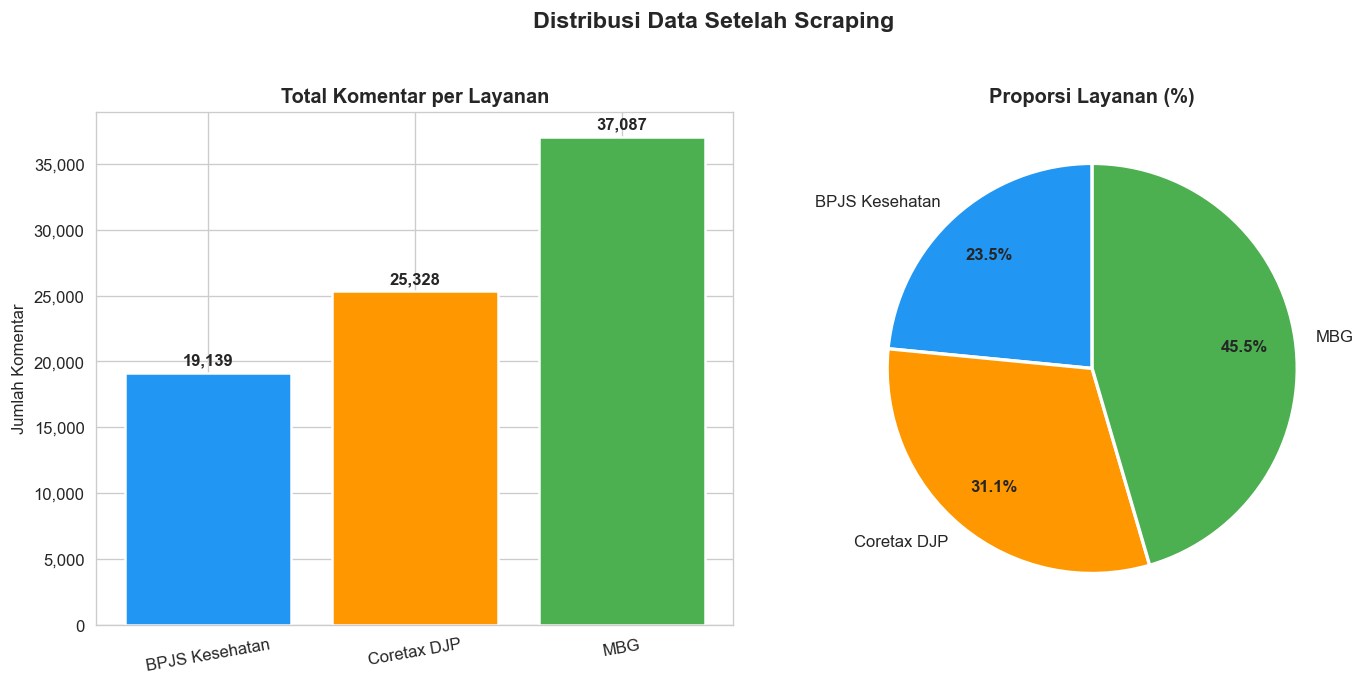

✅ Grafik disimpan: outputs/figures/proporsi_setelah_scraping.png

######################################################################
# Setelah Cleaning
######################################################################
RINGKASAN — Setelah Cleaning
Total baris (semua layanan + tidak diketahui): 80,163
Total baris (3 layanan dikenali)              : 80,163
  - BPJS Kesehatan  :  19,055 ( 23.8%)
  - Coretax DJP     :  24,949 ( 31.1%)
  - MBG             :  36,159 ( 45.1%)



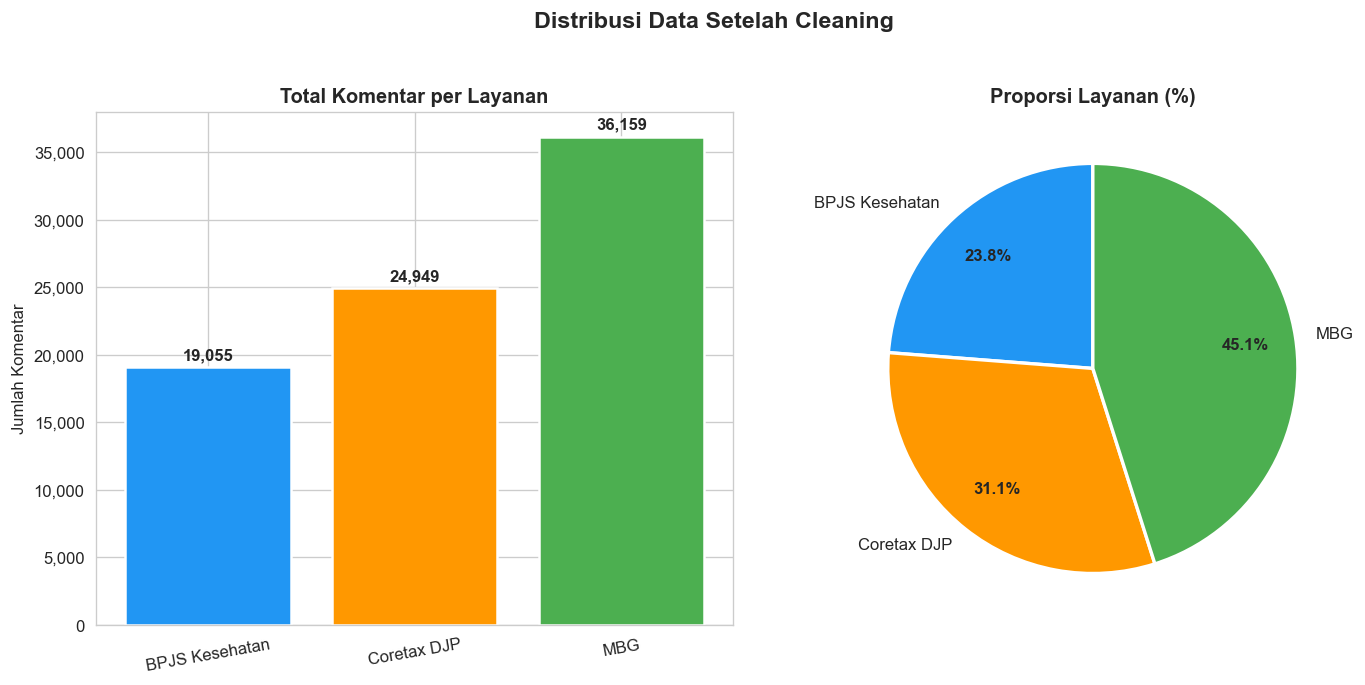

✅ Grafik disimpan: outputs/figures/proporsi_setelah_cleaning.png

######################################################################
# Setelah Labelling
######################################################################
RINGKASAN — Setelah Labelling
Total baris (semua layanan + tidak diketahui): 64,349
Total baris (3 layanan dikenali)              : 64,349
  - BPJS Kesehatan  :  16,238 ( 25.2%)   [Keluhan: 7,306 | Saran: 2,958 | Pujian: 5,974]
  - Coretax DJP     :  21,724 ( 33.8%)   [Keluhan: 16,060 | Saran: 2,455 | Pujian: 3,209]
  - MBG             :  26,387 ( 41.0%)   [Keluhan: 17,901 | Saran: 3,256 | Pujian: 5,230]



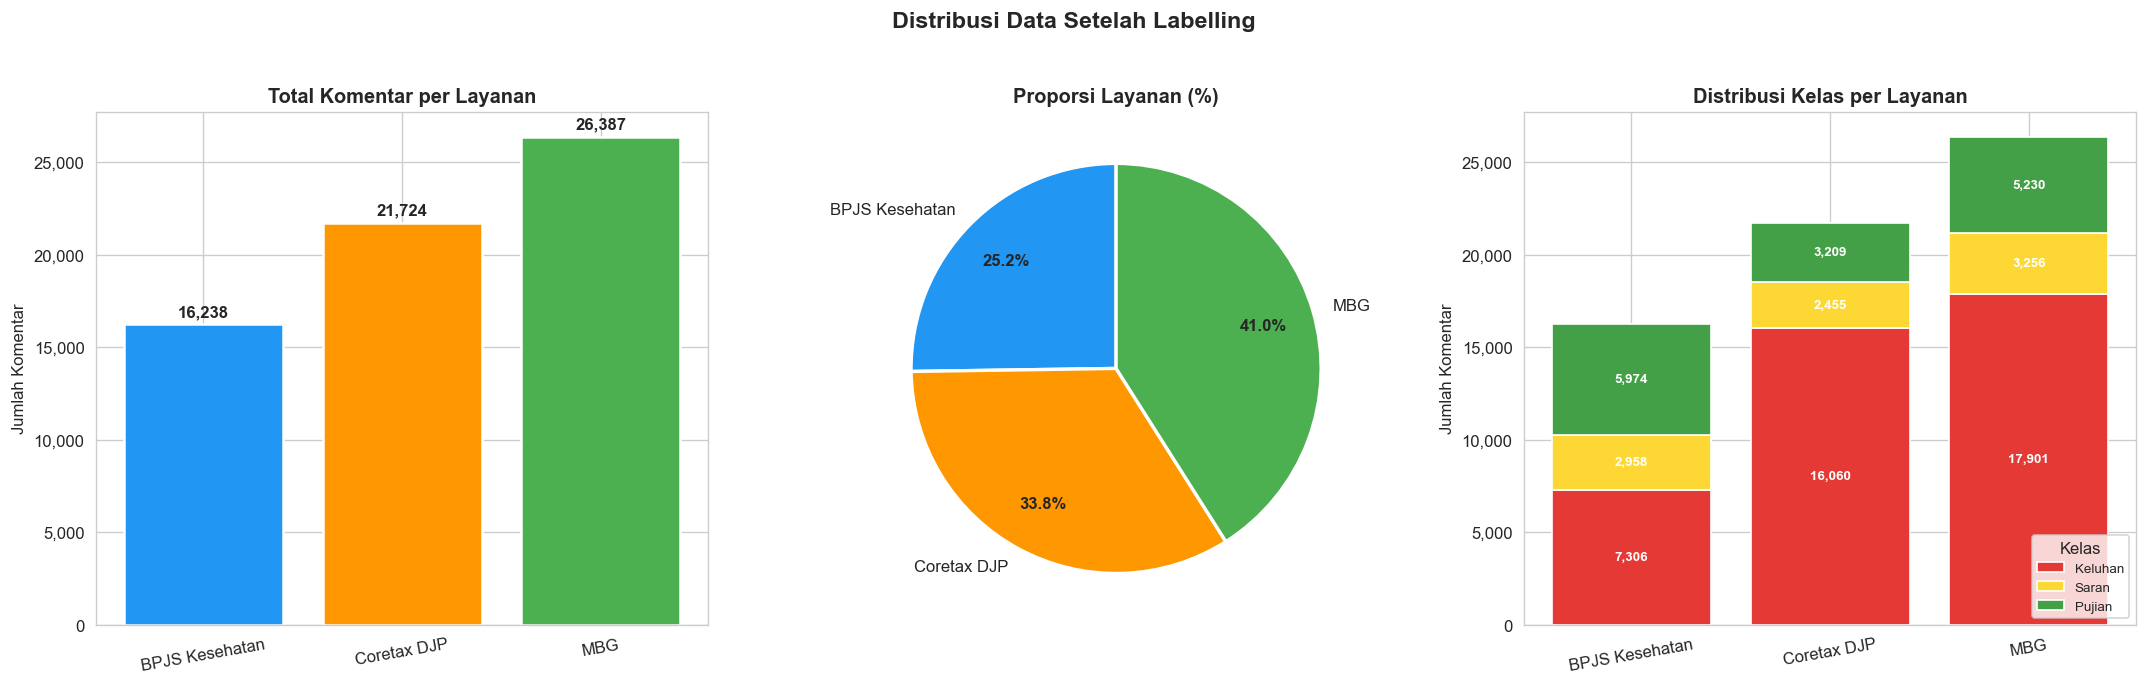

✅ Grafik disimpan: outputs/figures/proporsi_setelah_labelling.png

######################################################################
# Setelah Preprocessing XGBoost
######################################################################
RINGKASAN — Setelah Preprocessing XGBoost
Total baris (semua layanan + tidak diketahui): 59,864
Total baris (3 layanan dikenali)              : 59,864
  - BPJS Kesehatan  :  13,880 ( 23.2%)   [Keluhan: 7,240 | Saran: 2,891 | Pujian: 3,749]
  - Coretax DJP     :  20,876 ( 34.9%)   [Keluhan: 15,717 | Saran: 2,376 | Pujian: 2,783]
  - MBG             :  25,108 ( 41.9%)   [Keluhan: 17,440 | Saran: 2,948 | Pujian: 4,720]



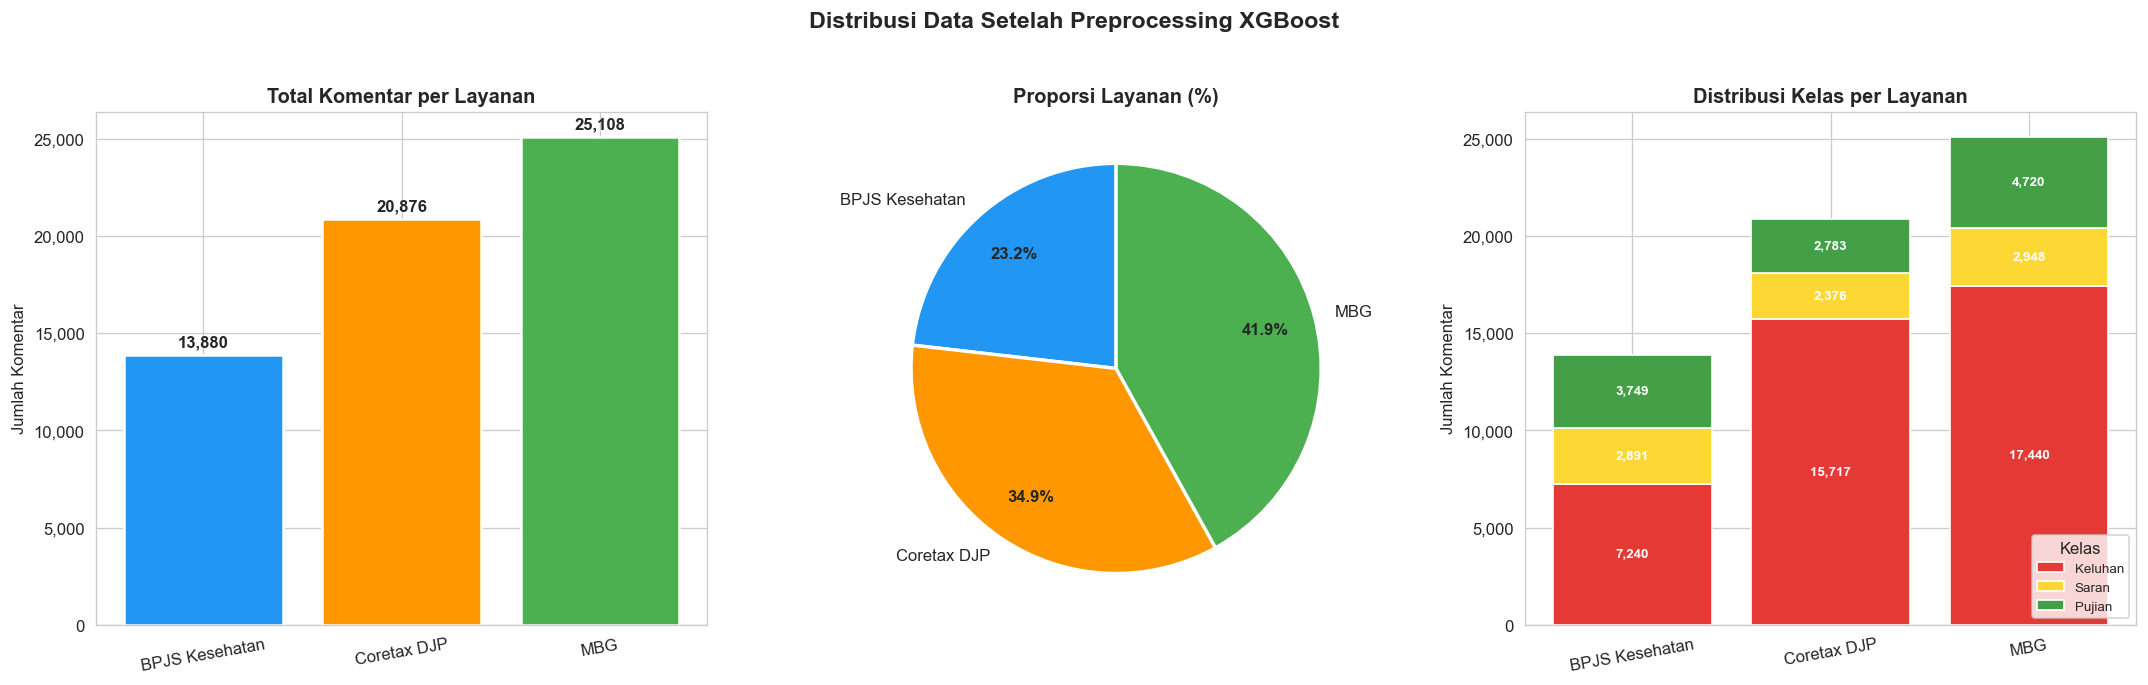

✅ Grafik disimpan: outputs/figures/proporsi_setelah_preprocessing_xgboost.png

######################################################################
# Setelah Preprocessing IndoBERT
######################################################################
RINGKASAN — Setelah Preprocessing IndoBERT
Total baris (semua layanan + tidak diketahui): 57,141
Total baris (3 layanan dikenali)              : 57,141
  - BPJS Kesehatan  :  12,832 ( 22.5%)   [Keluhan: 7,243 | Saran: 2,907 | Pujian: 2,682]
  - Coretax DJP     :  20,283 ( 35.5%)   [Keluhan: 15,679 | Saran: 2,393 | Pujian: 2,211]
  - MBG             :  24,026 ( 42.0%)   [Keluhan: 17,175 | Saran: 2,988 | Pujian: 3,863]



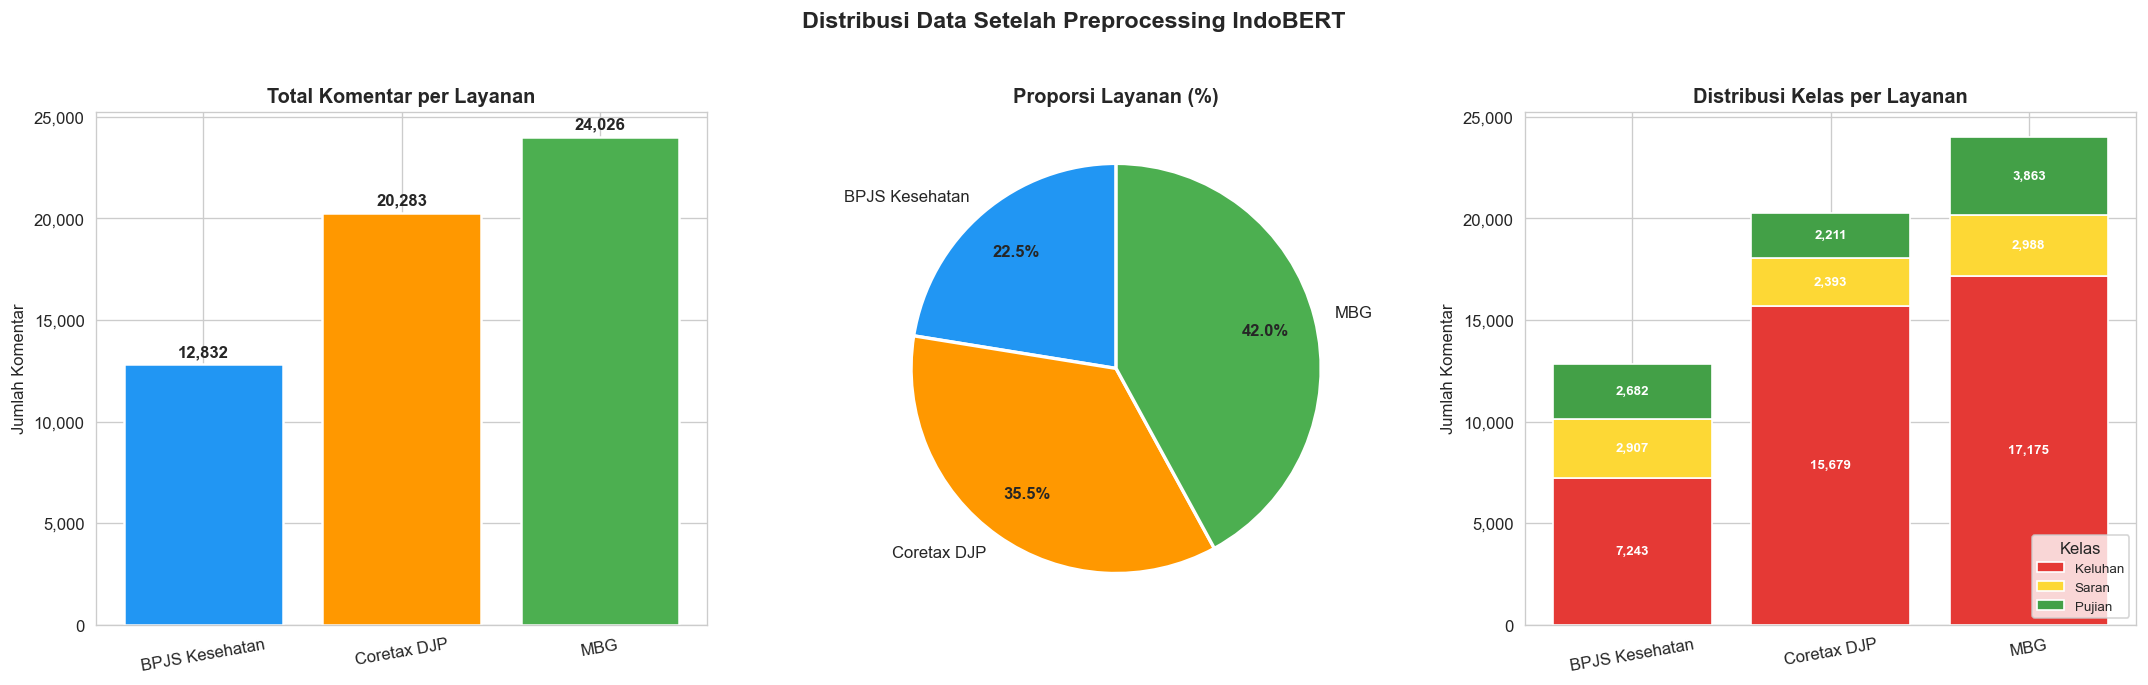

✅ Grafik disimpan: outputs/figures/proporsi_setelah_preprocessing_indobert.png


In [16]:
hasil_tahap = {}

for nama_tahap, cfg in TAHAPAN.items():
    print(f'\n{"#"*70}\n# {nama_tahap}\n{"#"*70}')
    df = muat_dan_petakan(cfg['path'], cfg['kolom_url'])
    if df is None:
        continue
    df, ada_label = tambah_kolom_kelas(df, cfg['kolom_label'])
    hasil_tahap[nama_tahap] = {'df': df, 'ada_label': ada_label}
    ringkasan_tahap(nama_tahap, df, ada_label)
    plot_tahap(nama_tahap, df, ada_label)


## 6. Perbandingan Antar Tahapan

### 6a. Jumlah Total Data di Tiap Tahapan (Data Reduction / Funnel)

Grafik ini memperlihatkan berapa banyak data yang "hilang" di tiap tahap pipeline
(mis. berapa banyak komentar dibuang saat cleaning).

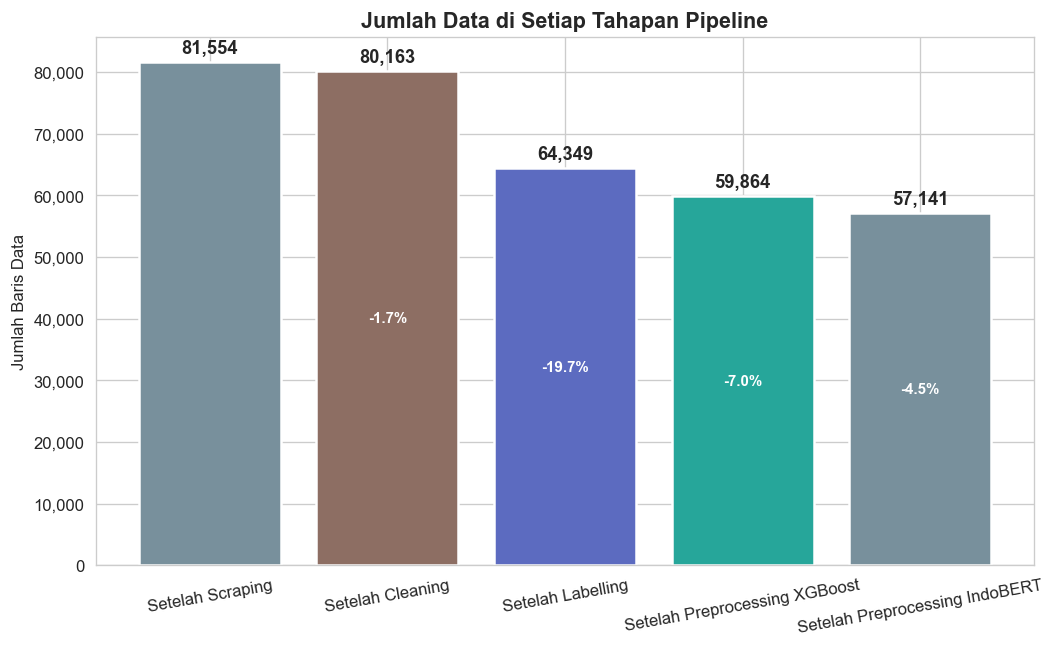

✅ Grafik disimpan: outputs/figures/jumlah_data_per_tahap.png


In [9]:
tahapan_ada = [t for t in TAHAPAN if t in hasil_tahap]
totals = [len(hasil_tahap[t]['df']) for t in tahapan_ada]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(tahapan_ada, totals, color=['#78909C', '#8D6E63', '#5C6BC0', '#26A69A'][:len(tahapan_ada)],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, totals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(totals)*0.01,
             f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    if bar is not bars[0]:
        idx = list(bars).index(bar)
        pct_drop = (totals[idx-1]-val)/totals[idx-1]*100 if totals[idx-1] else 0
        if pct_drop > 0.01:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.5,
                     f'-{pct_drop:.1f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')

ax.set_title('Jumlah Data di Setiap Tahapan Pipeline', fontweight='bold', fontsize=13)
ax.set_ylabel('Jumlah Baris Data')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.savefig('outputs/figures/jumlah_data_per_tahap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan: outputs/figures/jumlah_data_per_tahap.png')


### 6b. Proporsi per Layanan — Dibandingkan di Semua Tahapan

Kalau proporsi antar layanan bergeser drastis dari satu tahapan ke tahapan berikutnya
(misalnya BPJS turun tajam setelah cleaning), itu tanda bahwa proses cleaning/labelling
membuang data secara tidak merata antar layanan — penting disebut di skripsi.

layanan                         BPJS Kesehatan  Coretax DJP    MBG
Setelah Scraping                         23.47        31.06  45.48
Setelah Cleaning                         23.77        31.12  45.11
Setelah Labelling                        25.23        33.76  41.01
Setelah Preprocessing XGBoost            23.19        34.87  41.94
Setelah Preprocessing IndoBERT           22.46        35.50  42.05


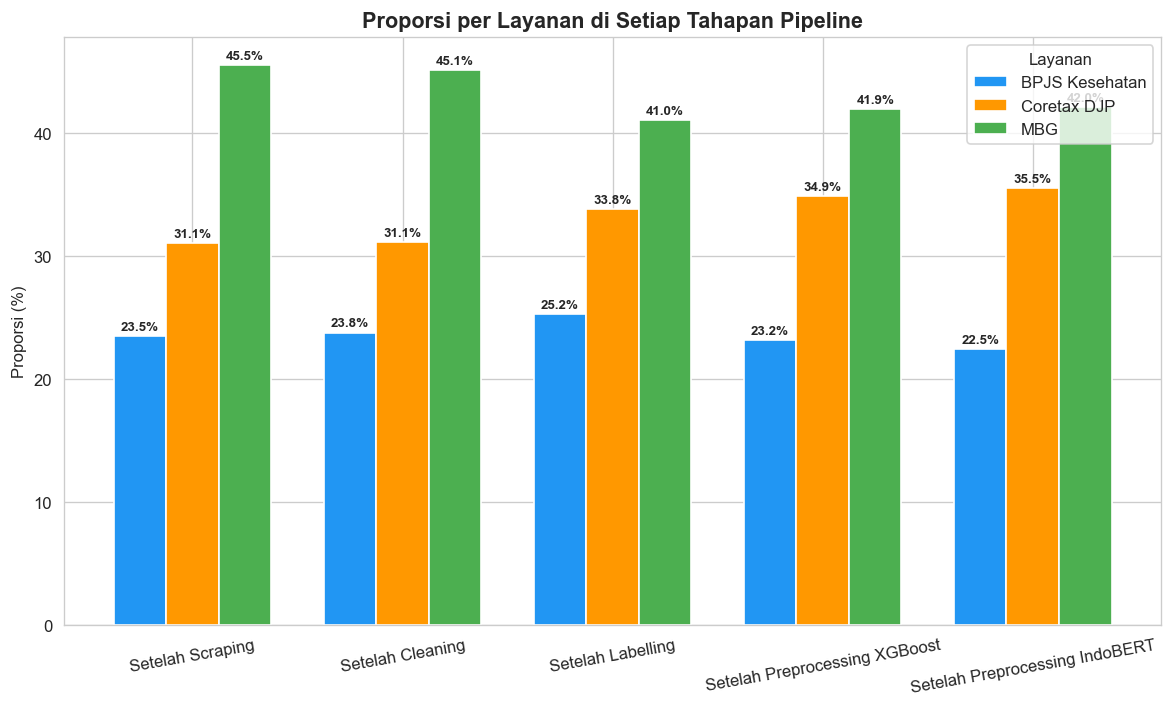

✅ Grafik disimpan: outputs/figures/proporsi_layanan_antar_tahap.png


In [10]:
pct_per_tahap = {}
for t in tahapan_ada:
    df_t = hasil_tahap[t]['df']
    df_t = df_t[df_t['layanan'].isin(LAYANAN_ORDER)]
    pct = df_t['layanan'].value_counts(normalize=True).reindex(LAYANAN_ORDER).fillna(0) * 100
    pct_per_tahap[t] = pct

pct_df = pd.DataFrame(pct_per_tahap).T  # index=tahapan, columns=layanan
print(pct_df.round(2))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(tahapan_ada))
width = 0.25
for i, layanan in enumerate(LAYANAN_ORDER):
    vals = pct_df[layanan].values
    ax.bar(x + (i-1)*width, vals, width, label=layanan, color=WARNA_LAYANAN[layanan], edgecolor='white')
    for xi, v in zip(x + (i-1)*width, vals):
        ax.text(xi, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(tahapan_ada, rotation=10)
ax.set_ylabel('Proporsi (%)')
ax.set_title('Proporsi per Layanan di Setiap Tahapan Pipeline', fontweight='bold', fontsize=13)
ax.legend(title='Layanan')
plt.tight_layout()
plt.savefig('outputs/figures/proporsi_layanan_antar_tahap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Grafik disimpan: outputs/figures/proporsi_layanan_antar_tahap.png')


### 6c. Proporsi Kelas — Dibandingkan di Tahapan yang Sudah Berlabel

Hanya tahapan yang punya kolom label (biasanya Labelling & Preprocessing) yang dibandingkan di sini.

kelas                           Keluhan  Saran  Pujian
Setelah Labelling                 64.13  13.47   22.40
Setelah Preprocessing XGBoost     67.48  13.72   18.80
Setelah Preprocessing IndoBERT    70.17  14.50   15.32


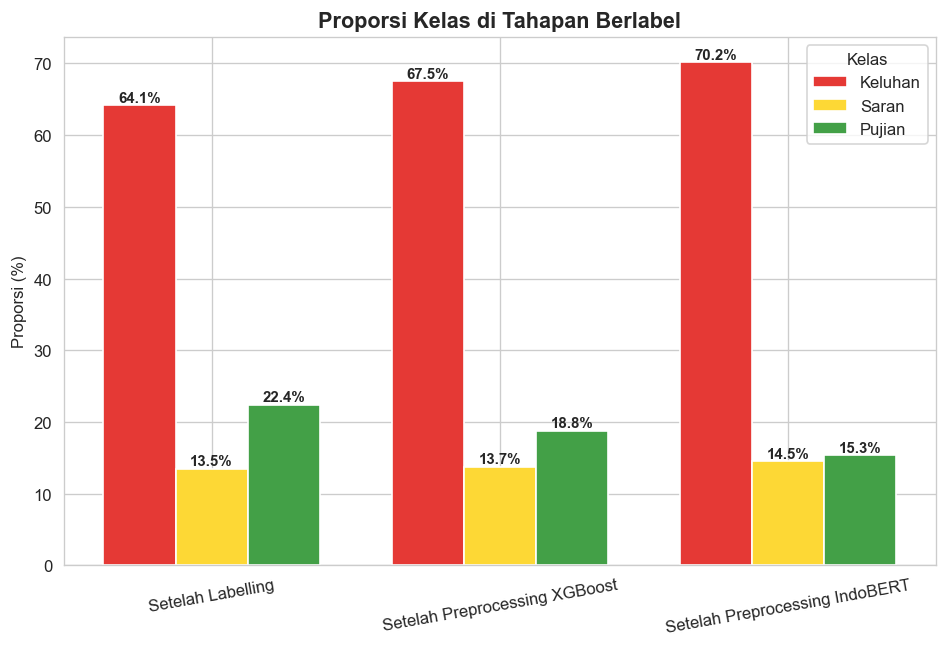

✅ Grafik disimpan: outputs/figures/proporsi_kelas_antar_tahap.png


In [11]:
tahapan_berlabel = [t for t in tahapan_ada if hasil_tahap[t]['ada_label']]

if len(tahapan_berlabel) >= 1:
    pct_kelas_per_tahap = {}
    for t in tahapan_berlabel:
        df_t = hasil_tahap[t]['df']
        df_t = df_t[df_t['layanan'].isin(LAYANAN_ORDER)]
        pct = df_t['kelas'].value_counts(normalize=True).reindex(KELAS_ORDER).fillna(0) * 100
        pct_kelas_per_tahap[t] = pct

    pct_kelas_df = pd.DataFrame(pct_kelas_per_tahap).T
    print(pct_kelas_df.round(2))

    fig, ax = plt.subplots(figsize=(8, 5.5))
    x = np.arange(len(tahapan_berlabel))
    width = 0.25
    for i, kelas in enumerate(KELAS_ORDER):
        vals = pct_kelas_df[kelas].values
        ax.bar(x + (i-1)*width, vals, width, label=kelas, color=WARNA_KELAS[kelas], edgecolor='white')
        for xi, v in zip(x + (i-1)*width, vals):
            ax.text(xi, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(tahapan_berlabel, rotation=10)
    ax.set_ylabel('Proporsi (%)')
    ax.set_title('Proporsi Kelas di Tahapan Berlabel', fontweight='bold', fontsize=13)
    ax.legend(title='Kelas')
    plt.tight_layout()
    plt.savefig('outputs/figures/proporsi_kelas_antar_tahap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Grafik disimpan: outputs/figures/proporsi_kelas_antar_tahap.png')
else:
    print('⚠️  Belum ada tahapan dengan kolom label yang terbaca -- lengkapi KOLOM_LABEL di Bagian 3.')


## 7. Ringkasan Teks untuk Skripsi

Teks siap-tempel yang merangkum jumlah & proporsi data di setiap tahapan pipeline.

In [12]:
print('=' * 70)
print('RINGKASAN PIPELINE DATA -- SIAP TEMPEL KE SKRIPSI')
print('=' * 70)
for t in tahapan_ada:
    df_t = hasil_tahap[t]['df']
    df_t3 = df_t[df_t['layanan'].isin(LAYANAN_ORDER)]
    print(f'\n📌 {t}: {len(df_t):,} baris total ({len(df_t3):,} baris teridentifikasi layanan)')
    for layanan in LAYANAN_ORDER:
        subset = df_t3[df_t3['layanan'] == layanan]
        pct = len(subset)/len(df_t3)*100 if len(df_t3) else 0
        line = f'   - {layanan}: {len(subset):,} ({pct:.1f}%)'
        if hasil_tahap[t]['ada_label']:
            line += '  [' + ', '.join(f'{k}: {len(subset[subset["kelas"]==k]):,}' for k in KELAS_ORDER) + ']'
        print(line)


RINGKASAN PIPELINE DATA -- SIAP TEMPEL KE SKRIPSI

📌 Setelah Scraping: 81,554 baris total (81,554 baris teridentifikasi layanan)
   - BPJS Kesehatan: 19,139 (23.5%)
   - Coretax DJP: 25,328 (31.1%)
   - MBG: 37,087 (45.5%)

📌 Setelah Cleaning: 80,163 baris total (80,163 baris teridentifikasi layanan)
   - BPJS Kesehatan: 19,055 (23.8%)
   - Coretax DJP: 24,949 (31.1%)
   - MBG: 36,159 (45.1%)

📌 Setelah Labelling: 64,349 baris total (64,349 baris teridentifikasi layanan)
   - BPJS Kesehatan: 16,238 (25.2%)  [Keluhan: 7,306, Saran: 2,958, Pujian: 5,974]
   - Coretax DJP: 21,724 (33.8%)  [Keluhan: 16,060, Saran: 2,455, Pujian: 3,209]
   - MBG: 26,387 (41.0%)  [Keluhan: 17,901, Saran: 3,256, Pujian: 5,230]

📌 Setelah Preprocessing XGBoost: 59,864 baris total (59,864 baris teridentifikasi layanan)
   - BPJS Kesehatan: 13,880 (23.2%)  [Keluhan: 7,240, Saran: 2,891, Pujian: 3,749]
   - Coretax DJP: 20,876 (34.9%)  [Keluhan: 15,717, Saran: 2,376, Pujian: 2,783]
   - MBG: 25,108 (41.9%)  [Kelu